FINITIST TOPOLOGY: The Menger Sponge & The Holographic Principle
Finitist Hardware Ceiling (Visualization): Depth = 3
Grid Resolution: 27x27x27
Fractal Dimension (D): 2.7268 (Information Density Scaling)

[1/3] Generating Finitist Menger Sponge...
  -> Finite Volume (Voxels): 8,000
  -> Finite Surface Area (Faces): 18,048
[2/3] Calculating theoretical divergence (Standard Math)...
[3/3] Generating Visualizations...
✓ Saved: finitist_menger_sponge_holographic.png


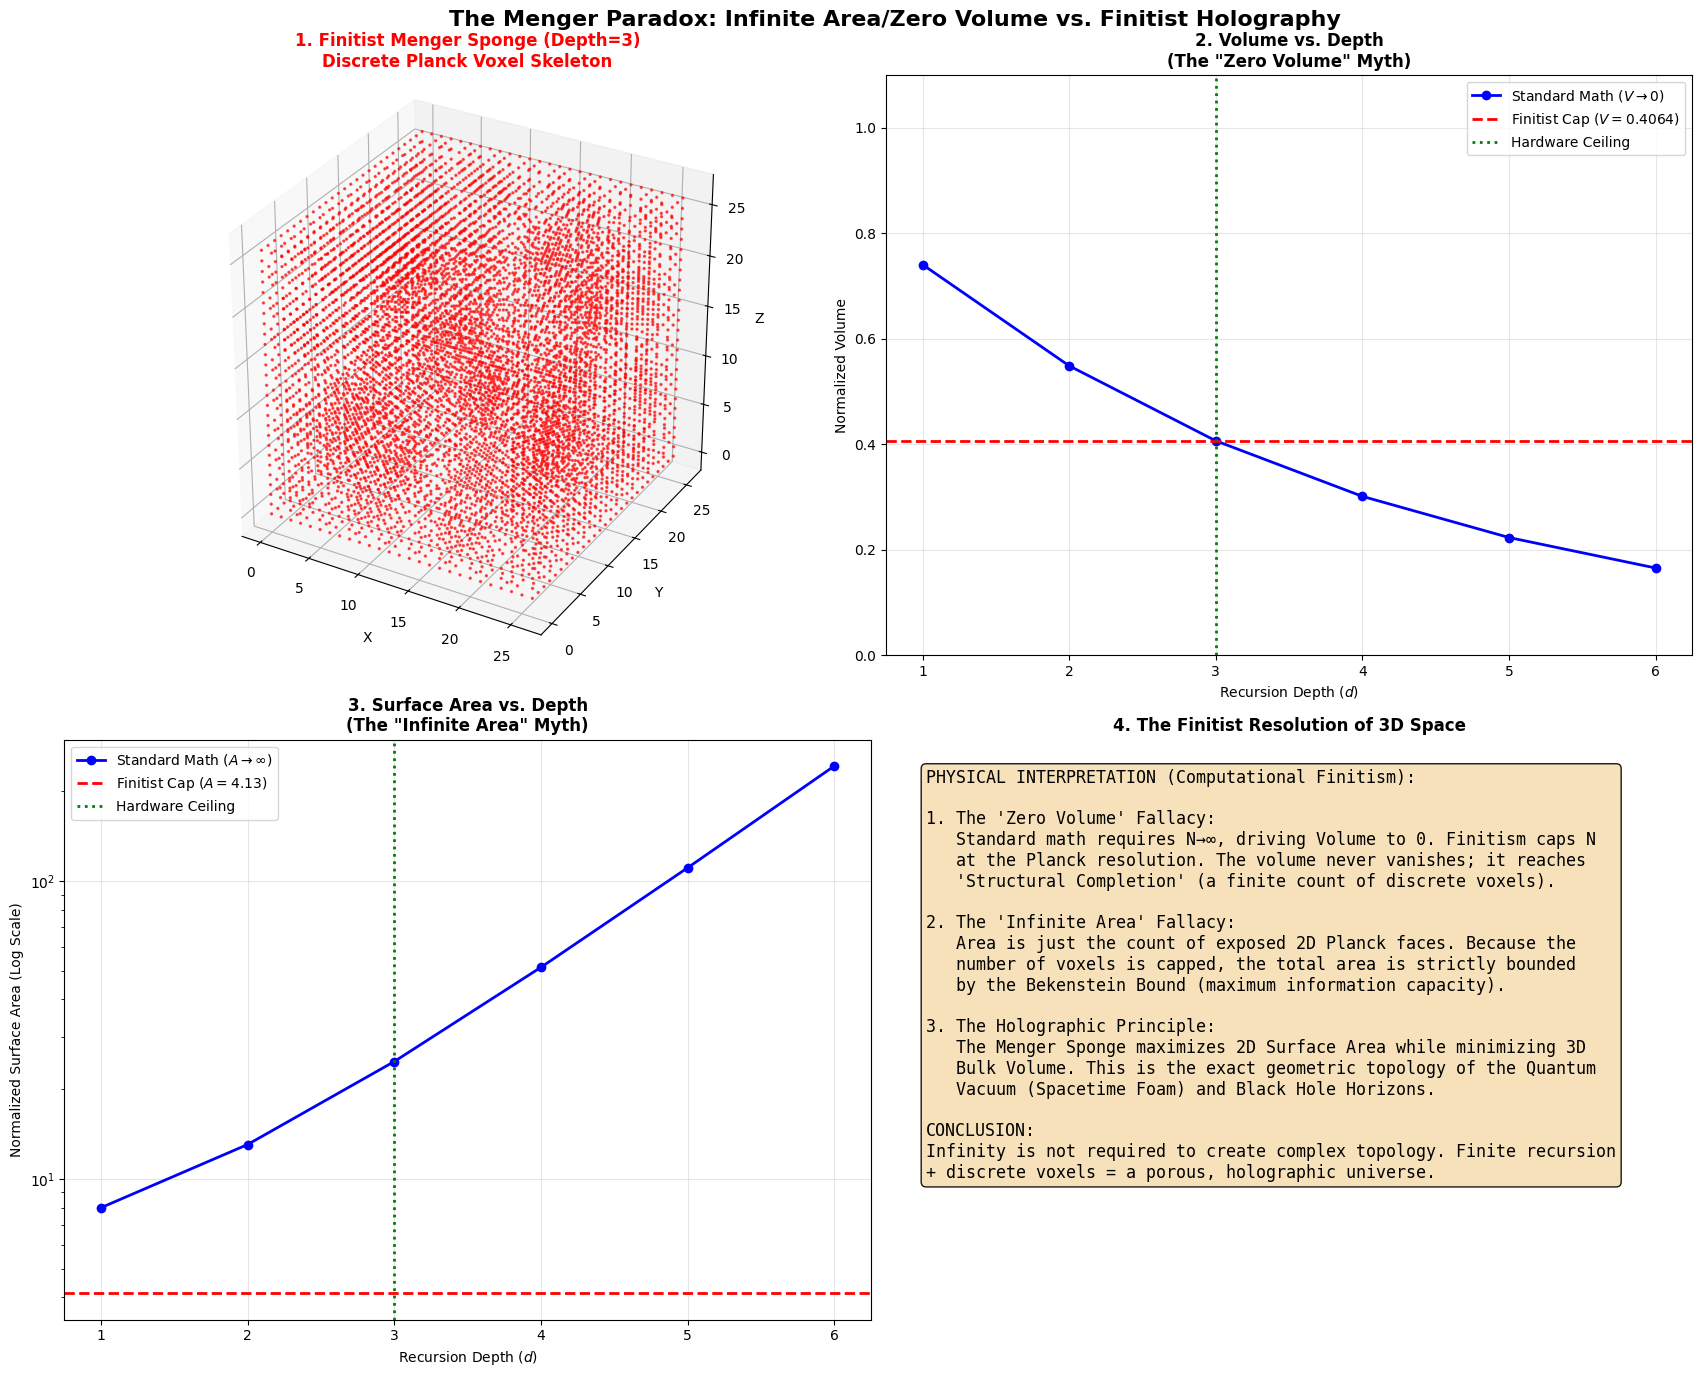


SIMULATION VERDICT: FINITIST MENGER SPONGE
Fractal Dimension D = 2.7268 (Scaling ratio of information density)
Finite Volume: 8,000 Planck voxels (Strictly > 0)
Finite Area: 18,048 exposed faces (Strictly < ∞)

Key Finitist Insights:
• The sponge does not vanish; it becomes a discrete, granular skeleton.
• The surface area does not diverge; it hits the Bekenstein Bound.
• This topology perfectly models the Holographic Principle:
  Maximizing boundary information (Area) while minimizing bulk (Volume).


In [2]:
"""
avenue_finitist_menger_sponge.py
====================================================================
FINITIST TOPOLOGY: The Menger Sponge (Zero Volume, Infinite Area Paradox)
Demonstrating how finite recursion resolves the 3D topological paradox
and reveals the Holographic Principle.

By Néstor E. Ramos


"""
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("FINITIST TOPOLOGY: The Menger Sponge & The Holographic Principle")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
MAX_DEPTH_VIS = 3   # Hardware ceiling for 3D visualization (3^3 = 27 voxels per side)
MAX_DEPTH_MATH = 6  # Mathematical horizon to show divergence vs. cap
ALPHABET = 9        # Modulo-9 finite alphabet context

print(f"Finitist Hardware Ceiling (Visualization): Depth = {MAX_DEPTH_VIS}")
print(f"Grid Resolution: {3**MAX_DEPTH_VIS}x{3**MAX_DEPTH_VIS}x{3**MAX_DEPTH_VIS}")
print(f"Fractal Dimension (D): {np.log(20)/np.log(3):.4f} (Information Density Scaling)")

# =============================================================================
# 2. VECTORIZED SPONGE GENERATION (Base-3 Coordinate Check)
# =============================================================================
def generate_menger_sponge(depth):
    """
    Generates a 3D boolean array of the Menger Sponge.
    A point (x,y,z) is REMOVED if, at any base-3 digit position,
    two or more of its coordinates have the middle digit (1).
    """
    size = 3**depth
    x, y, z = np.indices((size, size, size))
    in_sponge = np.ones((size, size, size), dtype=bool)

    for _ in range(depth):
        rx, x = x % 3, x // 3
        ry, y = y % 3, y // 3
        rz, z = z % 3, z // 3

        # Count how many coordinates are '1' (the center)
        ones_count = (rx == 1).astype(int) + (ry == 1).astype(int) + (rz == 1).astype(int)

        # If 2 or more are '1', the voxel is removed (it's a face-center or body-center)
        in_sponge &= (ones_count < 2)

    return in_sponge

# =============================================================================
# 3. CALCULATE BOUNDED PHYSICAL PROPERTIES
# =============================================================================
print("\n[1/3] Generating Finitist Menger Sponge...")
sponge = generate_menger_sponge(MAX_DEPTH_VIS)

# Volume = count of remaining voxels
volume_finitist = np.sum(sponge)

# Surface Area = count of exposed faces (voxel boundaries next to empty space)
def calculate_surface_area(sponge):
    padded = np.pad(sponge, 1, mode='constant', constant_values=False)
    area = 0
    # Check all 6 directions (x, y, z positive and negative)
    area += np.sum(sponge & ~padded[2:, 1:-1, 1:-1])
    area += np.sum(sponge & ~padded[:-2, 1:-1, 1:-1])
    area += np.sum(sponge & ~padded[1:-1, 2:, 1:-1])
    area += np.sum(sponge & ~padded[1:-1, :-2, 1:-1])
    area += np.sum(sponge & ~padded[1:-1, 1:-1, 2:])
    area += np.sum(sponge & ~padded[1:-1, 1:-1, :-2])
    return area

area_finitist = calculate_surface_area(sponge)

print(f"  -> Finite Volume (Voxels): {volume_finitist:,}")
print(f"  -> Finite Surface Area (Faces): {area_finitist:,}")

# =============================================================================
# 4. MATHEMATICAL DIVERGENCE (Standard vs. Finitist)
# =============================================================================
print("[2/3] Calculating theoretical divergence (Standard Math)...")
depths = np.arange(1, MAX_DEPTH_MATH + 1)

# Standard Math Formulas
vol_standard = (20/27)**depths
area_standard = 2 * (20/9)**depths + 4 * (8/9)**depths # Exact formula for Menger area

# Finitist Cap (Normalized to initial cube V=1, A=6)
vol_finitist_norm = volume_finitist / (3**MAX_DEPTH_VIS)**3
area_finitist_norm = area_finitist / (6 * (3**MAX_DEPTH_VIS)**2)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
print("[3/3] Generating Visualizations...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('The Menger Paradox: Infinite Area/Zero Volume vs. Finitist Holography',
             fontsize=16, fontweight='bold')

# --- Panel 1: 3D Voxel Cloud (The Finitist Structure) ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# Use scatter for performance and aesthetic "point cloud" look
xs, ys, zs = np.where(sponge)
ax1.scatter(xs, ys, zs, c='red', s=2, alpha=0.6)
ax1.set_title(f'1. Finitist Menger Sponge (Depth={MAX_DEPTH_VIS})\nDiscrete Planck Voxel Skeleton',
              fontsize=12, fontweight='bold', color='red')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_box_aspect([1,1,1])

# --- Panel 2: Volume Divergence (The "Zero Volume" Myth) ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(depths, vol_standard, 'b-o', linewidth=2, markersize=6, label='Standard Math ($V \\to 0$)')
ax2.axhline(y=vol_finitist_norm, color='red', linestyle='--', linewidth=2,
            label=f'Finitist Cap ($V={vol_finitist_norm:.4f}$)')
ax2.axvline(x=MAX_DEPTH_VIS, color='green', linestyle=':', linewidth=2, label='Hardware Ceiling')

ax2.set_title('2. Volume vs. Depth\n(The "Zero Volume" Myth)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Recursion Depth ($d$)'); ax2.set_ylabel('Normalized Volume')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

# --- Panel 3: Surface Area Divergence (The "Infinite Area" Myth) ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.semilogy(depths, area_standard, 'b-o', linewidth=2, markersize=6, label='Standard Math ($A \\to \\infty$)')
ax3.axhline(y=area_finitist_norm, color='red', linestyle='--', linewidth=2,
            label=f'Finitist Cap ($A={area_finitist_norm:.2f}$)')
ax3.axvline(x=MAX_DEPTH_VIS, color='green', linestyle=':', linewidth=2, label='Hardware Ceiling')

ax3.set_title('3. Surface Area vs. Depth\n(The "Infinite Area" Myth)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Recursion Depth ($d$)'); ax3.set_ylabel('Normalized Surface Area (Log Scale)')
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

# --- Panel 4: Physical Interpretation ---
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')

textstr = (
    "PHYSICAL INTERPRETATION (Computational Finitism):\n\n"
    "1. The 'Zero Volume' Fallacy:\n"
    "   Standard math requires N→∞, driving Volume to 0. Finitism caps N\n"
    "   at the Planck resolution. The volume never vanishes; it reaches\n"
    "   'Structural Completion' (a finite count of discrete voxels).\n\n"
    "2. The 'Infinite Area' Fallacy:\n"
    "   Area is just the count of exposed 2D Planck faces. Because the\n"
    "   number of voxels is capped, the total area is strictly bounded\n"
    "   by the Bekenstein Bound (maximum information capacity).\n\n"
    "3. The Holographic Principle:\n"
    "   The Menger Sponge maximizes 2D Surface Area while minimizing 3D\n"
    "   Bulk Volume. This is the exact geometric topology of the Quantum\n"
    "   Vacuum (Spacetime Foam) and Black Hole Horizons.\n\n"
    "CONCLUSION:\n"
    "Infinity is not required to create complex topology. Finite recursion\n"
    "+ discrete voxels = a porous, holographic universe."
)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', bbox=props, family='monospace')
ax4.set_title('4. The Finitist Resolution of 3D Space', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('finitist_menger_sponge_holographic.png', dpi=300, bbox_inches='tight')
print("✓ Saved: finitist_menger_sponge_holographic.png")
plt.show()

# =============================================================================
# VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION VERDICT: FINITIST MENGER SPONGE")
print("=" * 80)
print(f"Fractal Dimension D = {np.log(20)/np.log(3):.4f} (Scaling ratio of information density)")
print(f"Finite Volume: {volume_finitist:,} Planck voxels (Strictly > 0)")
print(f"Finite Area: {area_finitist:,} exposed faces (Strictly < ∞)")
print("\nKey Finitist Insights:")
print("• The sponge does not vanish; it becomes a discrete, granular skeleton.")
print("• The surface area does not diverge; it hits the Bekenstein Bound.")
print("• This topology perfectly models the Holographic Principle:")
print("  Maximizing boundary information (Area) while minimizing bulk (Volume).")
print("=" * 80)